# Exploratory Data Analysis

This notebook performs EDA for the Portfolio Replication dataset. It follows the existing project architecture by loading `results/data/picklefiles/data_loader.pkl` when available, or rebuilding it through `utils.data_loader.run_data_loader()` when the cache is missing.

Generated EDA figures are saved to `results/outputs/` with the `eda_` prefix.

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import pickle
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils import setup_logging
from utils.data_loader import DEFAULT_MONSTER_WEIGHTS, FUTURES_NAMES, run_data_loader

setup_logging(logging.INFO)
sns.set_theme(style='whitegrid', context='notebook')

PICKLE_DIR = Path('data') / 'picklefiles'
OUTPUTS_DIR = Path('outputs')
PICKLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Prepared Data

The data loader returns price levels, weekly returns, the Monster Index target, and the futures feature matrix used by the replication models.

In [2]:
cache_path = PICKLE_DIR / 'data_loader.pkl'

try:
    if not cache_path.exists():
        raise FileNotFoundError(cache_path)
    with cache_path.open('rb') as fh:
        data = pickle.load(fh)
    print(f'Loaded cached data from {cache_path}')
except Exception as exc:
    print(f'Cache unavailable or incompatible ({exc}); rebuilding from Excel.')
    data = run_data_loader(filepath=ROOT / 'data' / 'Dataset3_PortfolioReplicaStrategy.xlsx')

prices = data['prices']
returns = data['returns']
monster = data['monster']
X = data['X']
y = data['y']

index_cols = [col for col in returns.columns if col.endswith('Index')]
futures_cols = [col for col in returns.columns if col.endswith('Comdty')]

print(f'Prices : {prices.shape} | {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Returns: {returns.shape} | {returns.index.min().date()} to {returns.index.max().date()}')
print(f'Futures: {len(futures_cols)} instruments')
print(f'Target : {monster.name}, {len(monster)} observations')

Loaded cached data from data\picklefiles\data_loader.pkl
Prices : (705, 15) | 2007-10-23 to 2021-04-20
Returns: (704, 15) | 2007-10-30 to 2021-04-20
Futures: 11 instruments
Target : MonsterIndex, 704 observations


## 2. Data Quality Checks

In [3]:
quality = pd.DataFrame({
    'price_missing': prices.isna().sum(),
    'return_missing': returns.isna().sum(),
    'price_min': prices.min(),
    'price_max': prices.max(),
    'first_valid': prices.apply(lambda s: s.first_valid_index()),
    'last_valid': prices.apply(lambda s: s.last_valid_index()),
})

quality

,price_missing,return_missing,price_min,price_max,first_valid,last_valid
MXWO Index,0,0,705.350000,2944.050000,2007-10-23,2021-04-20
MXWD Index,0,0,176.100000,702.990000,2007-10-23,2021-04-20
LEGATRUU Index,0,0,342.247100,559.311700,2007-10-23,2021-04-20
HFRXGL Index,0,0,1021.400000,1415.110000,2007-10-23,2021-04-20
RX1 Comdty,0,0,110.200000,179.320000,2007-10-23,2021-04-20
TY1 Comdty,0,0,110.515625,140.328125,2007-10-23,2021-04-20
GC1 Comdty,0,0,732.700000,2001.200000,2007-10-23,2021-04-20
CO1 Comdty,0,0,19.330000,140.670000,2007-10-23,2021-04-20
ES1 Comdty,0,0,689.500000,4132.800000,2007-10-23,2021-04-20
VG1 Comdty,0,0,1873.000000,4476.000000,2007-10-23,2021-04-20


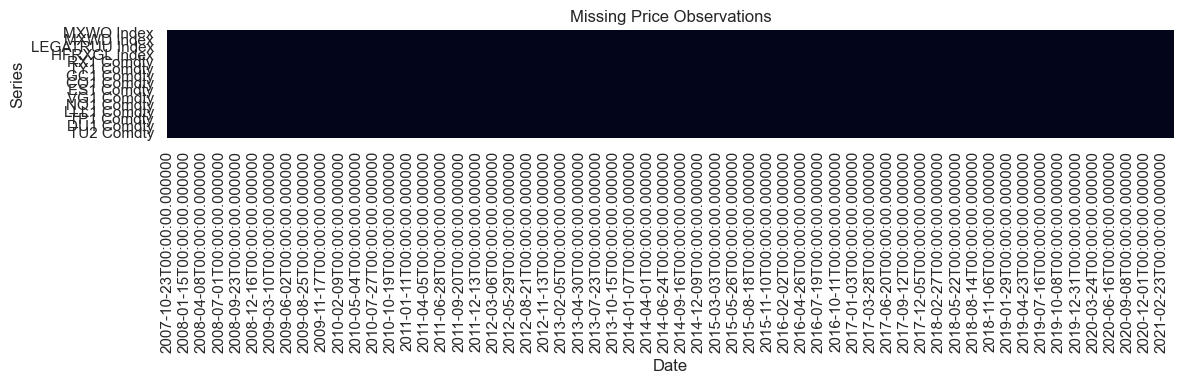

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(prices.isna().T, cbar=False, ax=ax)
ax.set_title('Missing Price Observations')
ax.set_xlabel('Date')
ax.set_ylabel('Series')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_01_missing_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Price-Level Overview

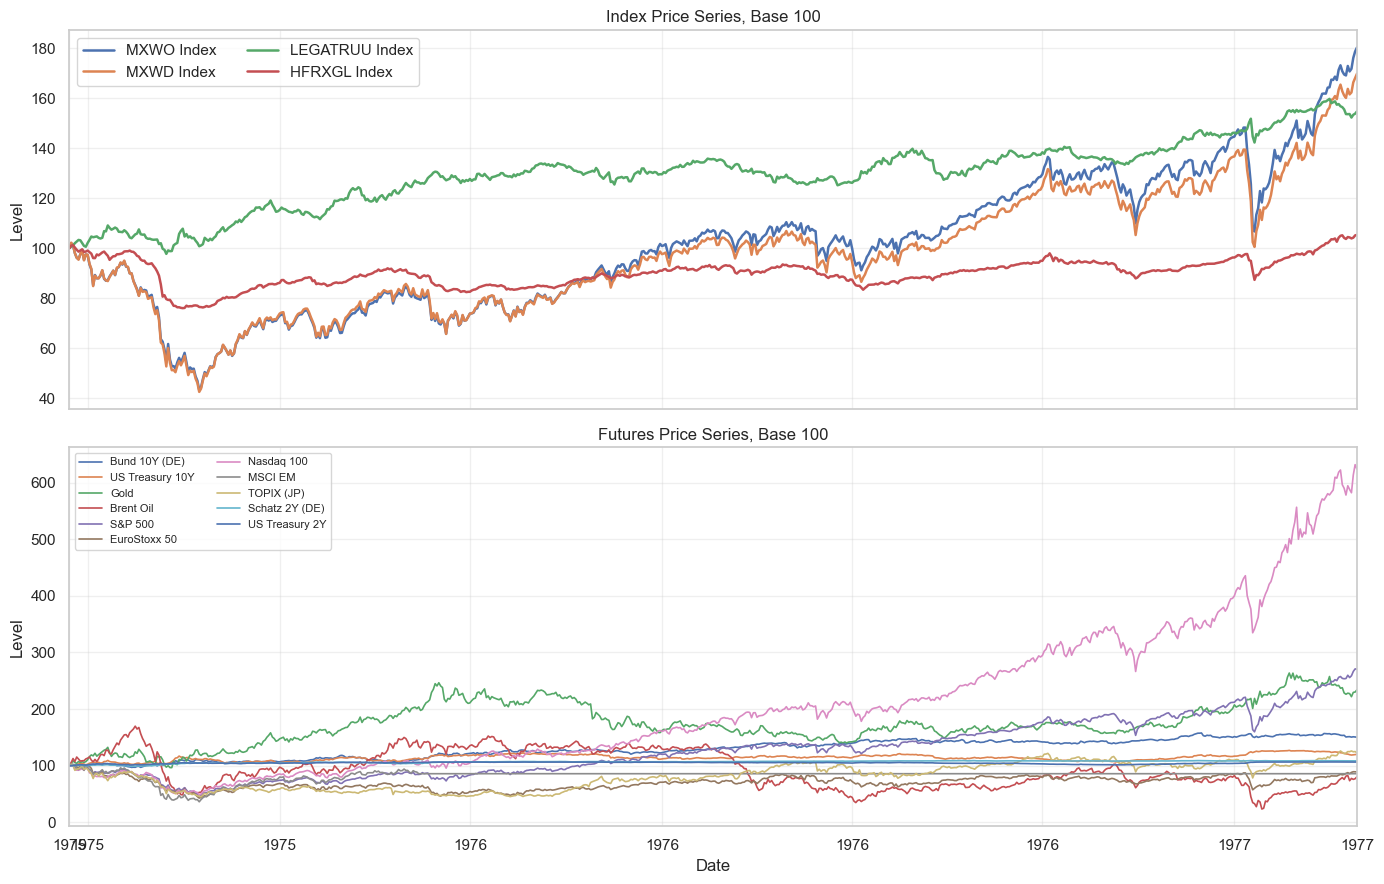

In [5]:
base100 = prices.div(prices.iloc[0]).mul(100)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

base100[index_cols].plot(ax=axes[0], linewidth=1.8)
axes[0].set_title('Index Price Series, Base 100')
axes[0].set_ylabel('Level')
axes[0].legend(loc='upper left', ncol=2)

base100[futures_cols].rename(columns=FUTURES_NAMES).plot(ax=axes[1], linewidth=1.2)
axes[1].set_title('Futures Price Series, Base 100')
axes[1].set_ylabel('Level')
axes[1].legend(loc='upper left', ncol=2, fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_02_base100_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Return Summary Statistics

In [6]:
def max_drawdown(series):
    wealth = (1 + series.dropna()).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return drawdown.min()


def cvar(series, alpha=0.05):
    threshold = series.quantile(alpha)
    return series[series <= threshold].mean()


all_returns = returns.copy()
all_returns['MonsterIndex'] = monster

summary = pd.DataFrame({
    'ann_return': all_returns.mean() * 52,
    'ann_vol': all_returns.std() * np.sqrt(52),
    'sharpe_0rf': (all_returns.mean() * 52) / (all_returns.std() * np.sqrt(52)),
    'skew': all_returns.skew(),
    'kurtosis': all_returns.kurtosis(),
    'weekly_var_5pct': all_returns.quantile(0.05),
    'weekly_cvar_5pct': all_returns.apply(cvar),
    'max_drawdown': all_returns.apply(max_drawdown),
})

summary.style.format('{:.2%}', subset=['ann_return', 'ann_vol', 'weekly_var_5pct', 'weekly_cvar_5pct', 'max_drawdown']).format('{:.2f}', subset=['sharpe_0rf', 'skew', 'kurtosis'])

,ann_return,ann_vol,sharpe_0rf,skew,kurtosis,weekly_var_5pct,weekly_cvar_5pct,max_drawdown
MXWO Index,5.90%,17.52%,0.34,-0.68,4.36,-3.88%,-6.10%,-57.61%
MXWD Index,5.51%,17.78%,0.31,-0.64,4.66,-3.81%,-6.21%,-58.39%
LEGATRUU Index,3.37%,5.34%,0.63,-0.33,4.12,-1.08%,-1.62%,-10.41%
HFRXGL Index,0.50%,4.78%,0.10,-2.30,13.70,-1.06%,-1.84%,-24.91%
RX1 Comdty,3.20%,6.14%,0.52,-0.52,1.61,-1.50%,-2.10%,-10.39%
TY1 Comdty,1.50%,5.63%,0.27,-0.41,3.09,-1.26%,-1.85%,-12.90%
GC1 Comdty,7.85%,17.72%,0.44,0.05,3.47,-3.73%,-5.35%,-43.18%
CO1 Comdty,6.51%,40.68%,0.16,1.07,16.38,-7.84%,-12.18%,-86.26%
ES1 Comdty,8.83%,17.01%,0.52,-1.04,5.17,-3.95%,-5.99%,-55.11%
VG1 Comdty,1.49%,21.70%,0.07,-0.09,3.60,-5.09%,-7.09%,-58.15%


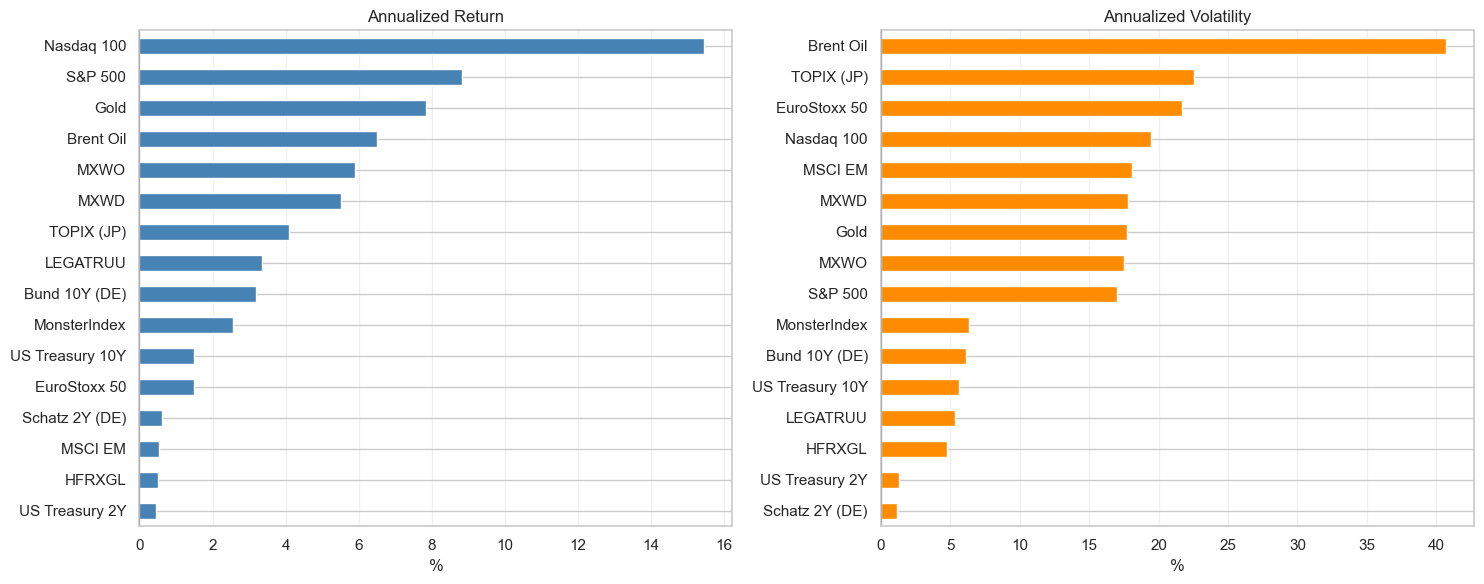

In [7]:
plot_summary = summary[['ann_return', 'ann_vol']].mul(100)
plot_summary.index = [FUTURES_NAMES.get(idx, idx.replace(' Index', '').replace(' Comdty', '')) for idx in plot_summary.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_summary['ann_return'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
plot_summary['ann_vol'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')

axes[0].set_title('Annualized Return')
axes[0].set_xlabel('%')
axes[1].set_title('Annualized Volatility')
axes[1].set_xlabel('%')

for ax in axes:
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_03_return_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Monster Index Composition

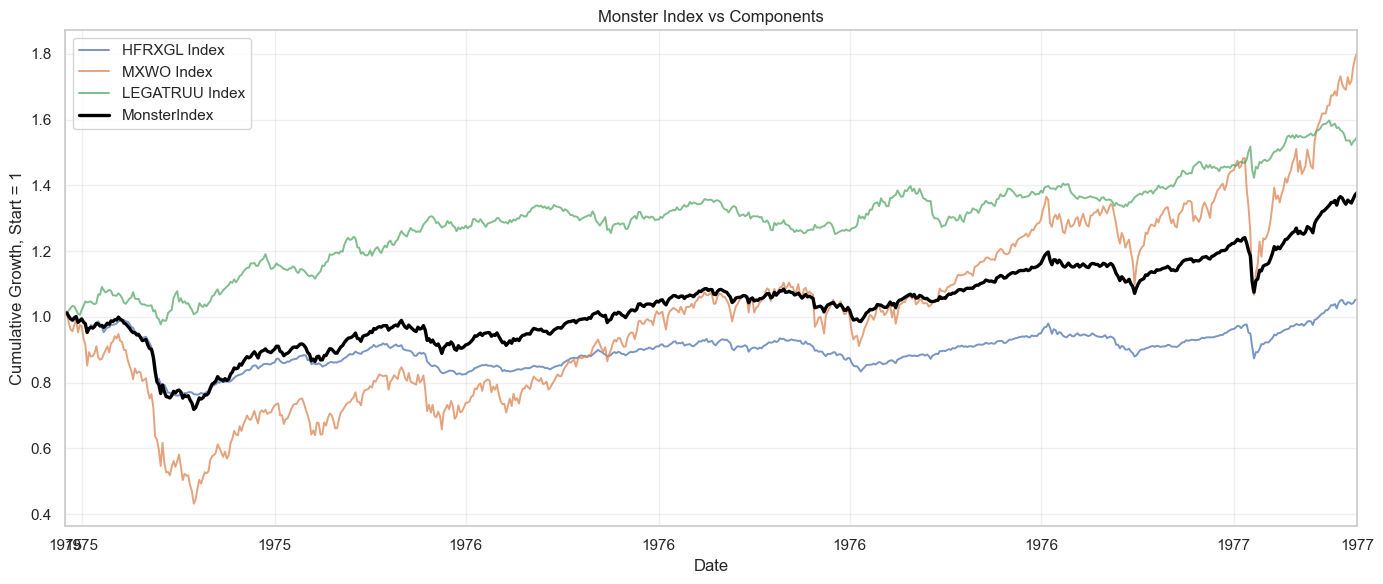

In [8]:
monster_components = list(DEFAULT_MONSTER_WEIGHTS)
component_cum = (1 + returns[monster_components]).cumprod()
monster_cum = (1 + monster).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
component_cum.plot(ax=ax, linewidth=1.4, alpha=0.75)
monster_cum.plot(ax=ax, color='black', linewidth=2.4, label='MonsterIndex')

ax.set_title('Monster Index vs Components')
ax.set_ylabel('Cumulative Growth, Start = 1')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_04_monster_components.png', dpi=150, bbox_inches='tight')
plt.show()

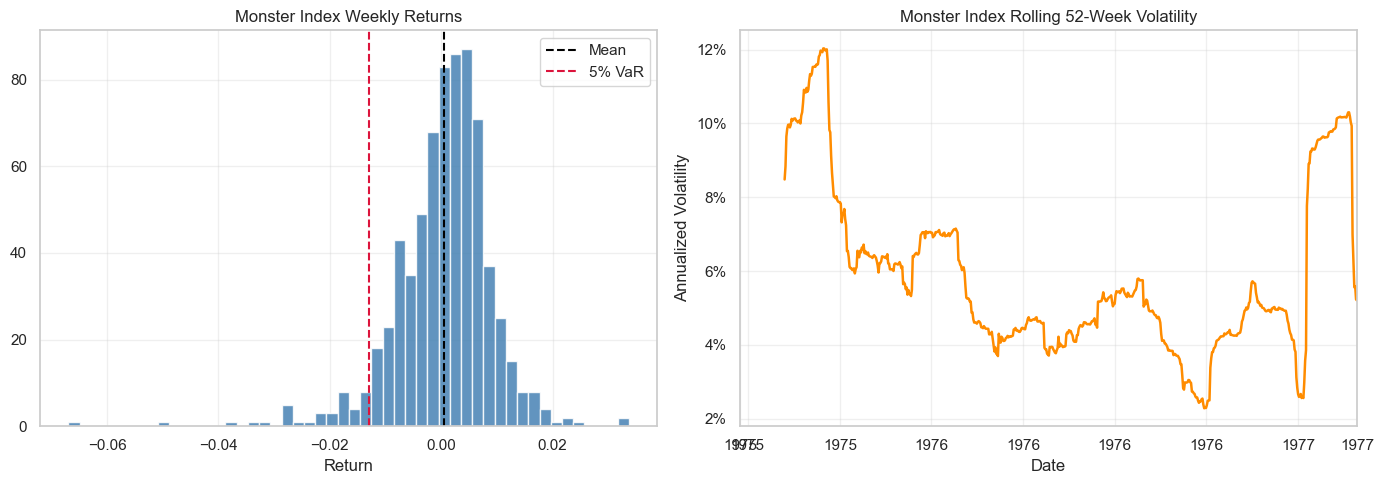

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(monster, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(monster.mean(), color='black', linestyle='--', linewidth=1.5, label='Mean')
axes[0].axvline(monster.quantile(0.05), color='crimson', linestyle='--', linewidth=1.5, label='5% VaR')
axes[0].set_title('Monster Index Weekly Returns')
axes[0].set_xlabel('Return')
axes[0].legend()

rolling_vol = monster.rolling(52).std() * np.sqrt(52)
rolling_vol.plot(ax=axes[1], color='darkorange', linewidth=1.8)
axes[1].set_title('Monster Index Rolling 52-Week Volatility')
axes[1].set_ylabel('Annualized Volatility')
axes[1].yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_05_monster_distribution_vol.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Replication Feature Relationships

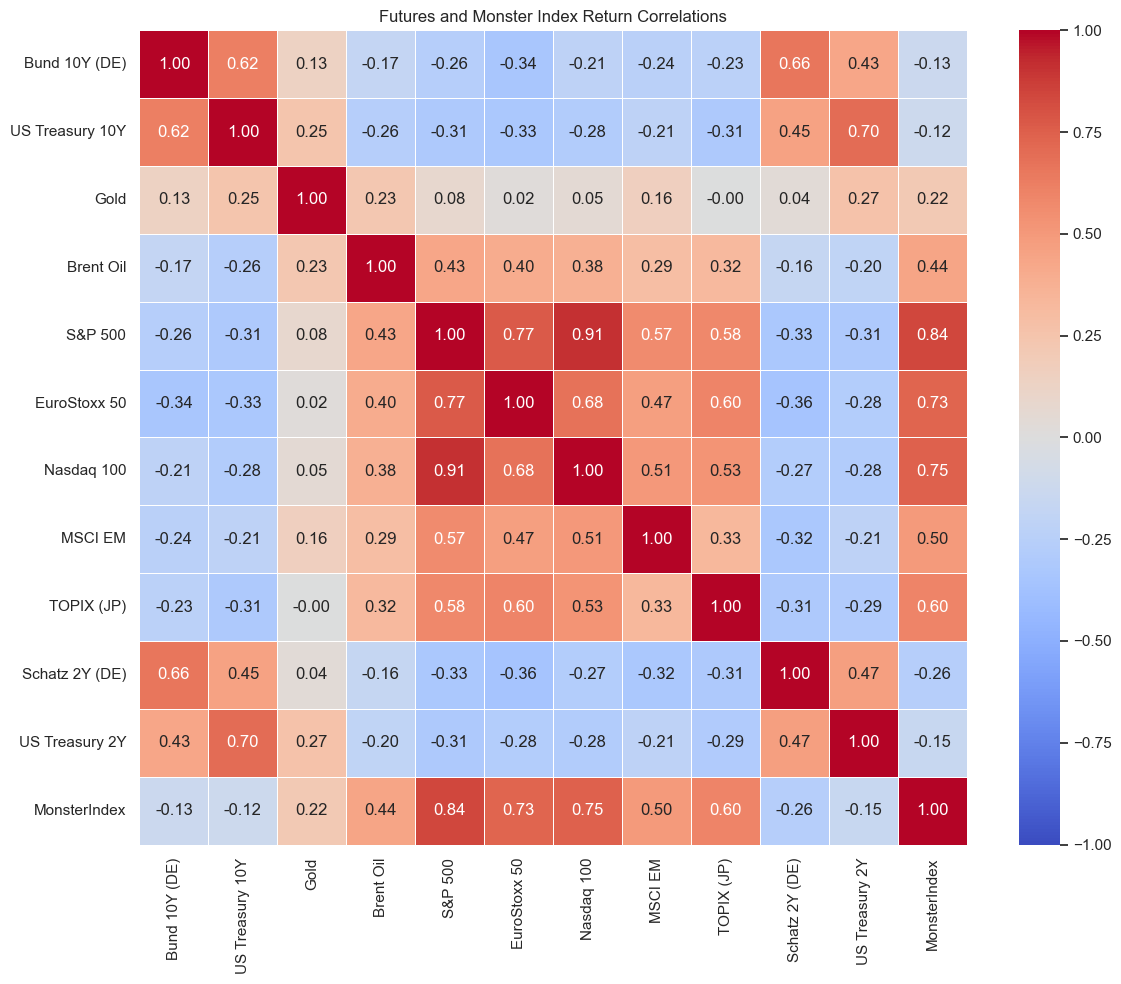

In [10]:
corr_data = X.copy()
corr_data['MonsterIndex'] = y
corr = corr_data.corr()
labels = {col: FUTURES_NAMES.get(col, col.replace(' Index', '').replace(' Comdty', '')) for col in corr.columns}

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr.rename(index=labels, columns=labels),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Futures and Monster Index Return Correlations')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_06_feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

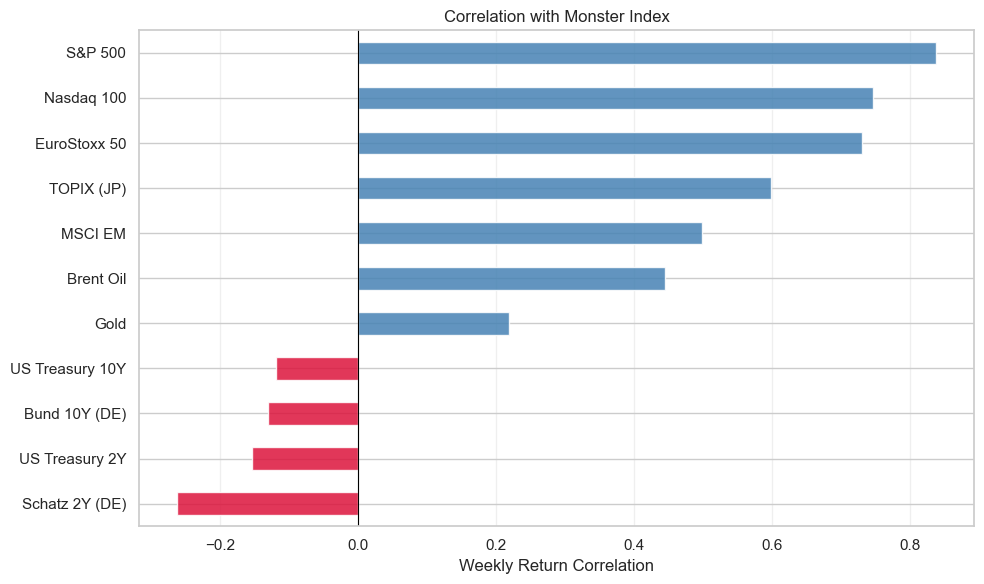

,corr_with_monster
S&P 500,0.837925
Nasdaq 100,0.746908
EuroStoxx 50,0.730608
TOPIX (JP),0.598764
MSCI EM,0.498685
Brent Oil,0.444804
Schatz 2Y (DE),-0.261666
Gold,0.218268
US Treasury 2Y,-0.152824
Bund 10Y (DE),-0.130681


In [11]:
target_corr = X.corrwith(y).sort_values()
target_corr.index = [FUTURES_NAMES.get(idx, idx.replace(' Comdty', '')) for idx in target_corr.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(target_corr >= 0, 'steelblue', 'crimson')
target_corr.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Monster Index')
ax.set_xlabel('Weekly Return Correlation')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_07_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr.sort_values(key=lambda s: s.abs(), ascending=False).to_frame('corr_with_monster')

## 7. Rolling Correlations to Target

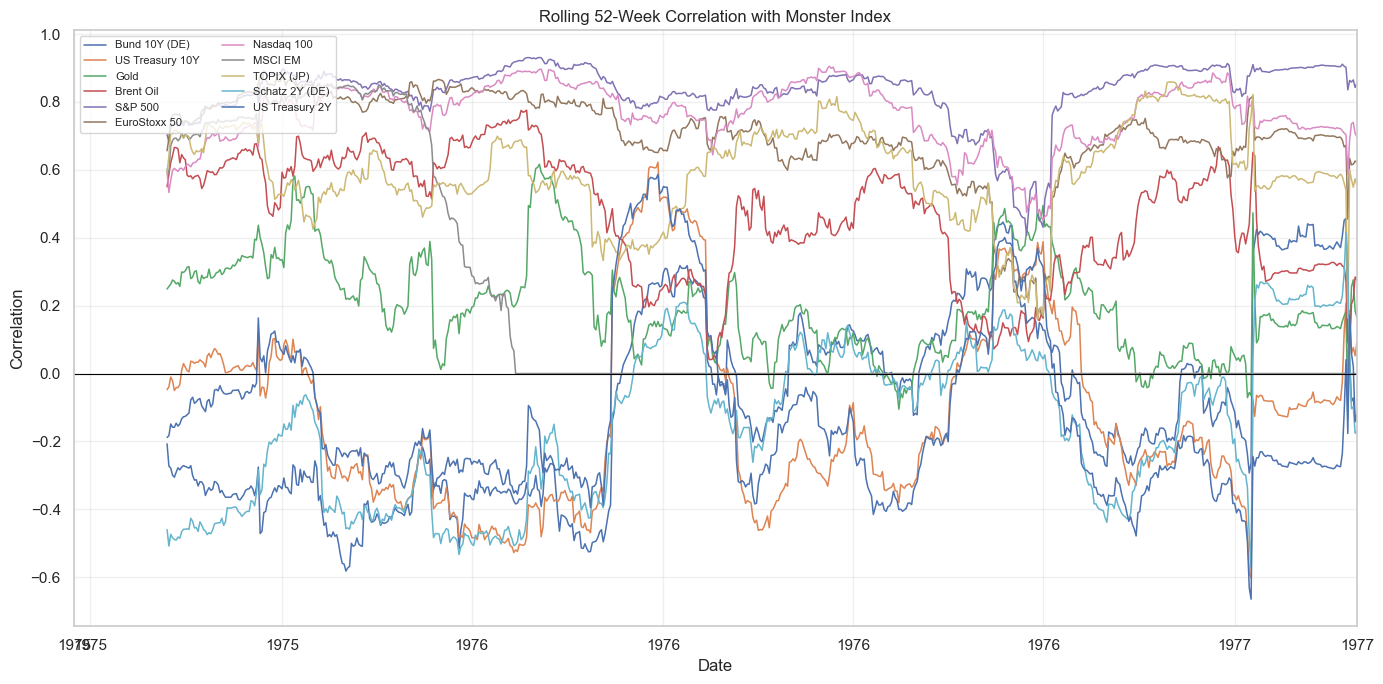

In [12]:
rolling_corr = X.apply(lambda col: col.rolling(52).corr(y))
rolling_corr = rolling_corr.rename(columns=FUTURES_NAMES)

fig, ax = plt.subplots(figsize=(14, 7))
rolling_corr.plot(ax=ax, linewidth=1.1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rolling 52-Week Correlation with Monster Index')
ax.set_ylabel('Correlation')
ax.legend(loc='upper left', ncol=2, fontsize=8)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_08_rolling_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Train-Test Context

The modeling notebooks use walk-forward estimation. This section gives quick context on how the target behaves before and after the regime split used later in the project.

In [13]:
split_date = pd.Timestamp('2020-02-21')
period = pd.Series(np.where(y.index <= split_date, 'pre_covid', 'post_covid'), index=y.index)

regime_stats = y.groupby(period).agg(['count', 'mean', 'std', 'min', 'max'])
regime_stats['ann_return'] = regime_stats['mean'] * 52
regime_stats['ann_vol'] = regime_stats['std'] * np.sqrt(52)
regime_stats[['count', 'ann_return', 'ann_vol', 'min', 'max']]

,count,ann_return,ann_vol,min,max
post_covid,61,0.093619,0.096797,-0.066939,0.032845
pre_covid,643,0.019220,0.059170,-0.049007,0.033772


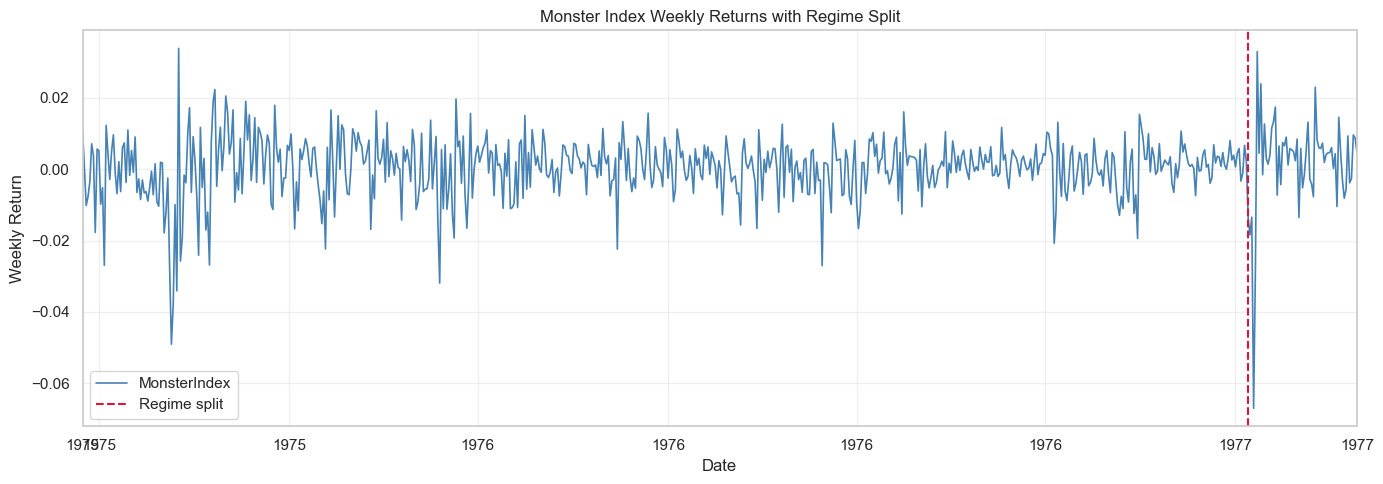

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
y.plot(ax=ax, color='steelblue', linewidth=1.2)
ax.axvline(split_date, color='crimson', linestyle='--', linewidth=1.5, label='Regime split')
ax.set_title('Monster Index Weekly Returns with Regime Split')
ax.set_ylabel('Weekly Return')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_09_target_regime_split.png', dpi=150, bbox_inches='tight')
plt.show()